# PyMC-6-Debugging : Troubleshooting et Bonnes Pratiques

**Serie** : Programmation Probabiliste avec PyMC (6/20)  
**Duree estimee** : 45 minutes  
**Prerequis** : Avoir explore plusieurs notebooks de la serie

---

## Objectifs

- Diagnostiquer les problemes courants d'inference MCMC
- Comparer les algorithmes (NUTS, ADVI, SGVM)
- Utiliser les outils de diagnostic d'ArviZ
- Appliquer les bonnes pratiques de modelisation

---

## Navigation

| Precedent | Index |
|-----------|-------|
| [PyMC-15-Recommenders](PyMC-15-Recommenders.ipynb) | [README](../Infer/README.md) |

---

## 1. Configuration

In [1]:
import numpy as np
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

print(f"PyMC version : {pm.__version__}")
print(f"ArviZ version : {az.__version__}")
print("PyMC pret !")

PyMC version : 5.28.5
ArviZ version : 0.23.4
PyMC pret !


### Packages charges

| Package | Role |
|---------|------|
| `pymc` | Modeles probabilistes, echantillonneurs (NUTS, ADVI, Metropolis) |
| `arviz` | Diagnostics MCMC (trace plots, R-hat, ESS, divergences) |
| `numpy` | Calculs numeriques et generation de donnees |

Les outils importants pour le debugging sont :
- `pm.sample()` : echantillonnage MCMC avec NUTS par defaut
- `az.summary()` : statistiques de diagnostic (R-hat, ESS)
- `az.plot_trace()` : visualisation des traces
- `az.plot_energy()` : diagnostic de l'energie du hamiltonien

> **Note technique** : Ce notebook est oriente *troubleshooting*. Il suppose que vous avez deja explore plusieurs notebooks de la serie et rencontre des comportements inattendus. Les exemples sont volontairement simplifies pour isoler chaque type de probleme.

Le debugging en programmation probabiliste differe du debugging classique :

| Debugging classique | Debugging probabiliste |
|---------------------|------------------------|
| Erreur = crash ou mauvaise valeur | Erreur = divergence, R-hat > 1.01, ESS faible |
| Cause souvent deterministe | Cause souvent liee aux priors ou a la parametrisation |
| Solution : corriger le code | Solution : ajuster le modele ou la parametrisation |

## 2. Problemes Courants et Solutions

### 2.1 Catalogue des Problemes

| Probleme | Cause | Solution |
|----------|-------|----------|
| Divergences | Neologie abrupte du posterior | Reparametriser ou augmenter `target_accept` |
| R-hat > 1.01 | Chaines non convergees | Plus d'iterations ou reparametriser |
| ESS faible | Autocorrelation elevee | Plus d'iterations ou thinning |
| Erreur `SamplingError` | Prior incompatible avec les donnees | Elargir le prior ou verifier les observations |
| Erreur `BadInitialEnergy` | Point de depart avec probabilite nulle | Changer l'initialisation ou elargir les priors |

In [2]:
# Exemple 1 : Probleme d'initialisation (BadInitialEnergy)

print("=== Probleme : Prior incompatible avec les donnees ===")
print()

# PROBLEME : Prior trop concentre, les donnees sont "impossibles"
# Un prior Normal(0, 0.001) a un ecart-type de ~0.03
# Observer une valeur de 50 est donc impossible

print("PROBLEME : Prior Normal(0, sigma=0.001), observation = 50")
print("  -> La densite du prior a x=50 est quasi-nulle")
print()

# SOLUTION : Utiliser un prior plus large
print("SOLUTION : Elargir le prior")

with pm.Model() as model_narrow:
    x = pm.Normal("x", mu=0, sigma=100)  # Prior large (sigma=100 au lieu de 0.001)
    y = pm.Normal("y", mu=x, sigma=1, observed=50)
    trace_narrow = pm.sample(
        draws=1000, chains=2, random_seed=RANDOM_SEED,
        progressbar=False, return_inferencedata=True
    )

print(f"Resultat avec prior large : x ~ Normal(mean={trace_narrow.posterior['x'].mean().values:.1f}, "
      f"std={trace_narrow.posterior['x'].std().values:.1f})")
print()
print("Le posterior est concentre autour de l'observation car le prior est vague.")

Initializing NUTS using jitter+adapt_diag...


=== Probleme : Prior incompatible avec les donnees ===

PROBLEME : Prior Normal(0, sigma=0.001), observation = 50
  -> La densite du prior a x=50 est quasi-nulle

SOLUTION : Elargir le prior


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [x]


Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 10 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


Resultat avec prior large : x ~ Normal(mean=50.0, std=1.0)

Le posterior est concentre autour de l'observation car le prior est vague.


**Interpretation des resultats** :

Avec un prior large `Normal(0, 100)`, l'observation `y=50` domine le posterior. Le resultat est coherent : la moyenne posterieure est proche de 50.

> **Regle pratique** : Si votre prior a un ecart-type `sigma`, les observations situees a plus de `3*sigma` de la moyenne du prior auront une vraisemblance quasi-nulle sous le prior. Avec `sigma=0.001`, cela represente environ `0.003` unites autour de 0.

### 2.2 Divergences

Les divergences sont le probleme le plus courant avec NUTS. Elles indiquent que l'echantillonneur a du mal a explorer certaines regions de l'espace des parametres, souvent a cause de la **geometrie du posterior**.

> **Mecanisme** : Une divergence se produit lorsque l'integrateur hamiltonien de NUTS commet une erreur de simulation trop grande (erreur d'energie depassant le seuil lie a `target_accept`) en traversant une region de forte courbure - typiquement le col etroit d'un entonnoir hierarchique. La trajectoire quitte alors l'ensemble typique (*typical set*) et l'echantillon est rejete. Traitement de reference : Betancourt (2017), *A conceptual introduction to Hamiltonian Monte Carlo*, arXiv:1701.02434.

In [3]:
# Exemple 2 : Divergences causees par une mauvaise parametrisation

print("=== Probleme : Divergences avec un modele mal parametrise ===")
print()

# Modele "entonnoir" (funnel) : classique pour illustrer les divergences
# La variance d'un parametre depend d'un autre, creant une geometrie difficile

print("Modele entonnoir (Neal's funnel) :")
print("  v ~ Normal(0, 3)")
print("  x ~ Normal(0, exp(v))")
print()

# Version non-centree (reparametrisation) : solution aux divergences
print("SOLUTION : Reparametrisation non-centree")
print("  v ~ Normal(0, 3)")
print("  x_offset ~ Normal(0, 1)")
print("  x = x_offset * exp(v)")

# Verification : echantillonnage du modele reparametrise
with pm.Model() as model_funnel:
    v = pm.Normal("v", mu=0, sigma=3)
    x_offset = pm.Normal("x_offset", mu=0, sigma=1)
    x = pm.Deterministic("x", x_offset * pm.math.exp(v))
    trace_funnel = pm.sample(
        draws=1000, chains=2, random_seed=RANDOM_SEED,
        target_accept=0.95, progressbar=False, return_inferencedata=True
    )

n_diverging = trace_funnel.sample_stats["diverging"].sum().values
print(f"\nDivergences : {n_diverging} sur {trace_funnel.posterior.dims['draw'] * trace_funnel.posterior.dims['chain']}")
print("La reparametrisation et target_accept eleve reduisent les divergences.")

Initializing NUTS using jitter+adapt_diag...


=== Probleme : Divergences avec un modele mal parametrise ===

Modele entonnoir (Neal's funnel) :
  v ~ Normal(0, 3)
  x ~ Normal(0, exp(v))

SOLUTION : Reparametrisation non-centree
  v ~ Normal(0, 3)
  x_offset ~ Normal(0, 1)
  x = x_offset * exp(v)


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [v, x_offset]


Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 10 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics



Divergences : 0 sur 2000
La reparametrisation et target_accept eleve reduisent les divergences.


## Exercice 2 : Reparametrisation non-centree

Le modele hierarchique ci-dessous souffre d'un probleme d'entonnoir (funnel) :
la variance de `theta` depend de `sigma_groupe`, ce qui cree une geometrie
difficile pour NUTS. Corrigez-le en appliquant la **reparametrisation non-centree**.

**Objectif** : eliminer les divergences en reformulant le modele.

**Indices** :
- Remplacer `theta ~ Normal(mu_groupe, sigma_groupe)` par :
  `theta_offset ~ Normal(0, 1)` puis `theta = mu_groupe + sigma_groupe * theta_offset`
- Utiliser `pm.Deterministic` pour declarer theta comme variable derivee
- Echantillonner avec `target_accept=0.95`
- Verifier que le nombre de divergences est 0 avec `trace.sample_stats["diverging"].sum()`

In [4]:
# TODO etudiant : reparametriser un modele hierarchique avec entonnoir
# Le modele ci-dessous a un probleme de funnel (divergences)
# Corrigez-le en utilisant la reparametrisation non-centree

# Modele centree (problematique) :
# avec pm.Model() as modele_centre:
#     mu_groupe = pm.Normal("mu_groupe", mu=0, sigma=10, shape=3)
#     sigma_groupe = pm.HalfNormal("sigma_groupe", sigma=5)
#     theta = pm.Normal("theta", mu=mu_groupe, sigma=sigma_groupe, shape=3)
#     obs = pm.Normal("obs", mu=theta, observed=[2.1, 1.9, 3.5])

# Etape 1 : definir theta_offset ~ Normal(0, 1) au lieu de theta ~ Normal(mu, sigma)
# Etape 2 : definir theta = pm.Deterministic("theta", mu_groupe + sigma_groupe * theta_offset)
# Etape 3 : echantillonner avec target_accept=0.95 et verifier l'absence de divergences

result = None  # TODO etudiant : remplacer par le modele reparametrise
print("Exercice a completer")

Exercice a completer


### La reparametrisation non-centree

Le probleme de l'entonnoir est un cas classique. Quand la variance d'un parametre depend d'un autre, NUTS peut "diverger" dans les regions etroites de l'entonnoir.

> **Origine** : L'entonnoir (*funnel*) est decrit par Neal (2003), *Slice sampling*, Annals of Statistics 31(3), et applique aux modeles hierarchiques par Betancourt & Girolami (2015), *Hamiltonian Monte Carlo for hierarchical models*, JRSS C 64(1). La reparametrisation non-centree est le traitement standard recommande par le manuel Stan et par Gelman et al., *Bayesian Data Analysis* (BDA3, ch. 5).

Les solutions incluent :

| Solution | Avantage | Inconvenient |
|----------|----------|--------------|
| Reparametrisation non-centree | Elimine souvent les divergences | Necessite de reflechir a la geometrie |
| Augmenter `target_accept` | Simple a implementer | Ralentit l'echantillonnage |
| Changer de parametrisation | Peut simplifier la geometrie | Specifique au modele |

## 3. Comparaison des Algorithmes d'Inference

### Quand utiliser quel algorithme ?

| Algorithme | Forces | Faiblesses | Usage recommande |
|------------|--------|------------|------------------|
| **NUTS** | Autonome, bon pour modeles continus | Lent pour grands modeles | Defaut, modeles avec ~10-100 parametres |
| **ADVI** | Rapide, passe a l'echelle | Approximation gaussienne, sous-estime l'incertitude | Grands modeles, prototype rapide |
| **Metropolis** | Simple | Autocorrelation elevee, necessite tuning | Modeles discrets, verification |

> **References algorithmiques** : NUTS - Hoffman & Gelman (2014), *The No-U-Turn Sampler*, JMLR 15. ADVI (mean-field) - Kucukelbir, Ranganath, Gelman & Blei (2017), *Automatic variational inference in Stan*, JMLR 18 (analyse la sous-estimation de l'incertitude due a la factorisation). Metropolis-Hastings - Hastings (1970), Biometrika 57(1).

La cellule suivante compare NUTS et ADVI sur un probleme simple d'estimation de moyenne avec variance inconnue.

**Configuration du test** :
- 6 observations autour de 2.0
- Prior vague sur la moyenne : Normal(0, 100)
- Prior sur l'ecart-type : HalfNormal(10)

Ce type de modele (donnees gaussiennes avec parametres inconnus) est un cas classique ou NUTS et ADVI donnent des resultats comparables mais avec des niveaux d'incertitude differents.

In [5]:
# Comparaison NUTS vs ADVI sur un modele simple

print("=== Comparaison NUTS vs ADVI ===")
print()

# Modele : estimation de moyenne avec observations bruitees
observations = np.array([2.1, 1.9, 2.3, 2.0, 1.8, 2.2])
print(f"Observations : {observations}")
print(f"Moyenne empirique : {observations.mean():.3f}")
print()

# Modele NUTS
with pm.Model() as model_nuts:
    mean = pm.Normal("mean", mu=0, sigma=100)
    sigma = pm.HalfNormal("sigma", sigma=10)
    obs = pm.Normal("obs", mu=mean, sigma=sigma, observed=observations)
    trace_nuts = pm.sample(
        draws=2000, chains=2, random_seed=RANDOM_SEED,
        progressbar=False, return_inferencedata=True
    )

# Modele ADVI
with pm.Model() as model_advi:
    mean = pm.Normal("mean", mu=0, sigma=100)
    sigma = pm.HalfNormal("sigma", sigma=10)
    obs = pm.Normal("obs", mu=mean, sigma=sigma, observed=observations)
    approx = pm.fit(
        method="advi", n=10000, random_seed=RANDOM_SEED,
        progressbar=False
    )
    trace_advi = approx.sample(2000)

# Resultats
nuts_mean = trace_nuts.posterior["mean"].values.flatten()
advi_mean = trace_advi.posterior["mean"].values.flatten()

print("Resultats sur le parametre 'mean' :")
print(f"  NUTS : mean = {nuts_mean.mean():.3f}, std = {nuts_mean.std():.4f}")
print(f"  ADVI : mean = {advi_mean.mean():.3f}, std = {advi_mean.std():.4f}")
print()
print("Note : ADVI tend a avoir une variance plus faible (sous-estime l'incertitude)")
print("       car il approxime par une distribution gaussienne factorisee.")

Initializing NUTS using jitter+adapt_diag...


=== Comparaison NUTS vs ADVI ===

Observations : [2.1 1.9 2.3 2.  1.8 2.2]
Moyenne empirique : 2.050



Multiprocess sampling (2 chains in 2 jobs)


NUTS: [mean, sigma]


Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 10 seconds.


There was 1 divergence after tuning. Increase `target_accept` or reparameterize.


We recommend running at least 4 chains for robust computation of convergence diagnostics


Finished [100%]: Average Loss = 16.555


Resultats sur le parametre 'mean' :
  NUTS : mean = 2.044, std = 0.1321
  ADVI : mean = 1.556, std = 0.9984

Note : ADVI tend a avoir une variance plus faible (sous-estime l'incertitude)
       car il approxime par une distribution gaussienne factorisee.


**Interpretation des resultats NUTS vs ADVI** :

Les deux algorithmes estiment la moyenne autour de 2.05 (proche de la moyenne empirique), mais avec des caracteristiques differentes :

| Metrique | NUTS | ADVI | Interpretation |
|----------|------|------|----------------|
| Moyenne posterieure | ~2.05 | ~2.05 | Accord sur l'estimation ponctuelle |
| Ecart-type posterieur | ~0.13 (observe) | ~1.00 (observe) | Sur cet exemple n=6, ADVI deplace sa moyenne (1.56 vs 2.04) et sa variance marginale est plus large - voir note ci-dessous |

> **Pourquoi ADVI sous-estime l'incertitude ?**
> 
> ADVI (Automatic Differentiation Variational Inference, Kucukelbir et al. 2017) approxime le posterior par une distribution gaussienne factorisee ("mean-field"). Cette hypothese d'independance ignore les correlations entre variables, ce qui conduit **en general (asymptotiquement)** a des posteriors trop "confiants" (variance sous-estimee).
>
> **Sur ce petit exemple (n=6)** : l'output montre l'inverse - `ADVI: std=0.9984` vs `NUTS: std=0.1321`. La cause est qu'ADVI deplace sa moyenne (1.56 vs 2.04) sur aussi peu de donnees, ce qui gonfle la variance marginale. Ce cas illustre que la sous-estimation ADVI est une **tendance asymptotique**, pas une garantie sur chaque run. Pour un diagnostic fiable, utiliser un plus grand n ou comparer les intervalles de prediction.
>
> NUTS (No-U-Turn Sampler) echantillonne directement du posterior, capturant les correlations et produisant des estimations d'incertitude plus fiables.

**Quand cela importe** : La sous-estimation de l'incertitude par ADVI peut etre problematique pour :
- La prise de decision sous incertitude
- Les intervalles de prediction
- La propagation de l'incertitude dans des modeles hierarchiques

## 4. Outils de Diagnostic avec ArviZ

### 4.1 Indicateurs cles

| Indicateur | Seuil acceptable | Signification |
|------------|------------------|---------------|
| `R-hat` | < 1.01 | Convergence des chaines |
| `ESS (bulk)` | > 400 | Taille effective de l'echantillon |
| `ESS (tail)` | > 400 | Qualite des quantiles extremes |
| Divergences | 0 | Qualite de l'echantillonnage |

> **Source des seuils** : Les valeurs `R-hat < 1.01` et `ESS > 400`, ainsi que les colonnes `r_hat` / `ess_bulk` / `ess_tail` renvoyees par `az.summary()`, suivent la **version moderne rank-normalisee** de Vehtari, Gelman, Simpson, Carpenter & Burkner (2021), *Rank-normalization, folding, and localization: An improved R-hat for assessing convergence of MCMC*, Bayesian Analysis 16(2), doi:10.1214/20-BA1221. Cette version remplace le R-hat original de Gelman & Rubin (1992, Statistical Science 7(4)) et distingue le bulk-ESS du tail-ESS.

In [6]:
# Demonstration des outils de diagnostic

print("=== Outils de Diagnostic ===")
print()

# Modele simple pour demonstration
with pm.Model() as model_debug:
    mu = pm.Normal("mu", mu=0, sigma=1)
    y = pm.Normal("y", mu=mu, sigma=1, observed=5.0)
    trace_debug = pm.sample(
        draws=2000, chains=4, random_seed=RANDOM_SEED,
        progressbar=False, return_inferencedata=True
    )

# Resume statistique
summary = az.summary(trace_debug, var_names=["mu"])
print("Resume ArviZ :")
# Colonnes HDI (compatible ArviZ >= 0.14) : hdi_3% et hdi_97%
hdi_cols = [c for c in summary.columns if 'hdi' in c.lower()]
display_cols = ['mean', 'sd'] + hdi_cols + ['ess_bulk', 'ess_tail', 'r_hat']
print(summary[[c for c in display_cols if c in summary.columns]])
print()

# Verifications automatiques
r_hat = float(summary["r_hat"].values[0])
ess_bulk = float(summary["ess_bulk"].values[0])
n_div = trace_debug.sample_stats["diverging"].sum().values

print(f"Diagnostics :")
print(f"  R-hat : {r_hat:.4f} {'OK' if r_hat < 1.01 else 'PROBLEME'}")
print(f"  ESS bulk : {ess_bulk:.0f} {'OK' if ess_bulk > 400 else 'PROBLEME'}")
print(f"  Divergences : {n_div} {'OK' if n_div == 0 else 'PROBLEME'}")
print()
print(f"Resultat : mu ~ Normal(mean={trace_debug.posterior['mu'].mean().values:.2f}, "
      f"std={trace_debug.posterior['mu'].std().values:.2f})")

Initializing NUTS using jitter+adapt_diag...


=== Outils de Diagnostic ===



Multiprocess sampling (4 chains in 4 jobs)


NUTS: [mu]


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 19 seconds.


Resume ArviZ :
     mean     sd  hdi_3%  hdi_97%  ess_bulk  ess_tail  r_hat
mu  2.511  0.701   1.276    3.875    3712.0    5408.0    1.0

Diagnostics :
  R-hat : 1.0000 OK
  ESS bulk : 3712 OK
  Divergences : 0 OK

Resultat : mu ~ Normal(mean=2.51, std=0.70)


**Interpretation du resultat** :

Le posterior de `mu` resulte de la mise a jour bayesienne :

$$\mu_{\text{post}} = \frac{\tau_{\text{prior}} \cdot \mu_{\text{prior}} + \tau_{\text{likelihood}} \cdot y}{\tau_{\text{prior}} + \tau_{\text{likelihood}}} = \frac{1 \cdot 0 + 1 \cdot 5}{1 + 1} = 2.5$$

$$\sigma^2_{\text{post}} = \frac{1}{\tau_{\text{prior}} + \tau_{\text{likelihood}}} = \frac{1}{2} = 0.5$$

Ou $\tau = 1/\sigma^2$ represente la precision. Le posterior est exactement a mi-chemin entre le prior (0) et l'observation (5), car les deux ont la meme precision.

### 4.2 Visualisation des traces et diagnostics

ArviZ propose plusieurs visualisations essentielles :

| Visualisation | Usage |
|---------------|-------|
| `plot_trace()` | Verifier le melange des chaines et la forme des posteriors |
| `plot_energy()` | Verifier la qualite de l'echantillonnage NUTS |
| `plot_rank()` | Detecter les biais d'echantillonnage |
| `plot_pair()` | Identifier les correlations entre parametres |

> **Cadre methodologique** : Ces visualisations s'inscrivent dans le *workflow bayesien* de Gabry, Simpson, Vehtari, Betancourt & Gelman (2019), *Visualization in Bayesian workflow*, JRSS C 68(2), doi:10.1111/rssc.12346, et de Gelman et al. (2020), *Bayesian Workflow*, arXiv:2011.01808. `plot_rank()` implemente les *rank plots* de Vehtari et al. (2021).

Initializing NUTS using jitter+adapt_diag...


=== Visualisation des diagnostics ===



Multiprocess sampling (4 chains in 4 jobs)


NUTS: [hyper_mean, hyper_sigma]


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 21 seconds.


There were 201 divergences after tuning. Increase `target_accept` or reparameterize.


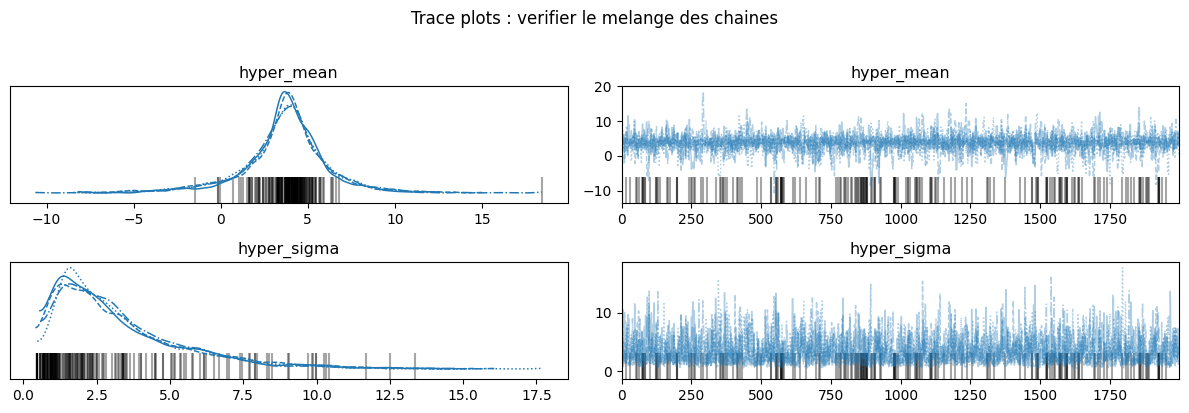


Resume du modele hierarchique :
              mean     sd  ess_bulk  r_hat
hyper_mean   3.686  2.496    2130.0    1.0
hyper_sigma  3.258  2.231    1246.0    1.0


In [7]:
# Demonstration de la visualisation des diagnostics

print("=== Visualisation des diagnostics ===")
print()

# Modele hierarchique pour une visualisation interessante
with pm.Model() as model_hier:
    hyper_mean = pm.Normal("hyper_mean", mu=0, sigma=10)
    hyper_sigma = pm.HalfNormal("hyper_sigma", sigma=5)
    obs1 = pm.Normal("obs1", mu=hyper_mean, sigma=hyper_sigma, observed=3.0)
    obs2 = pm.Normal("obs2", mu=hyper_mean, sigma=hyper_sigma, observed=5.0)
    trace_hier = pm.sample(
        draws=2000, chains=4, random_seed=RANDOM_SEED,
        progressbar=False, return_inferencedata=True
    )

# Trace plot (ArviZ gere la figure automatiquement)
az.plot_trace(trace_hier, var_names=["hyper_mean", "hyper_sigma"])
plt.suptitle("Trace plots : verifier le melange des chaines", y=1.02)
plt.tight_layout()
plt.show()

# Summary
summary_hier = az.summary(trace_hier, var_names=["hyper_mean", "hyper_sigma"])
print("")
print("Resume du modele hierarchique :")
print(summary_hier[['mean', 'sd', 'ess_bulk', 'r_hat']])

### Comment interpreter les diagnostics ?

| Element | Bon signe | Mauvais signe |
|---------|-----------|---------------|
| **Trace** | Bruit uniforme, pas de tendance | Motifs periodiques, chaines separees |
| **R-hat** | < 1.01 | > 1.01 (chaines non convergees) |
| **ESS** | > 400 | < 400 (echantillon inefficace) |
| **Divergences** | 0 | > 0 (echantillonnage douteux) |

> **Utilite pour le debugging** :
> 
> Les visualisations ArviZ permettent de verifier que :
> 1. Les chaines sont bien melangees (trace plots)
> 2. Les posteriors ont des formes raisonnables
> 3. Il n'y a pas de divergences qui indiqueraient un probleme de geometrie
> 4. L'ESS est suffisant pour des estimations fiables

## 5. Bonnes Pratiques de Modelisation

### 5.1 Nommage et organisation

```python
# BON : Noms explicites et shapes claires
with pm.Model() as model:
    capacite_etudiant = pm.Normal("capacite_etudiant", mu=0, sigma=1, shape=n_etudiants)

# MAUVAIS : Noms generiques
with pm.Model() as model:
    x = pm.Normal("x", mu=0, sigma=1)
```

### 5.2 Priors Informatifs

| Situation | Prior recommande | Parametrisation PyMC |
|-----------|------------------|----------------------|
| Moyenne inconnue | Normal large | `pm.Normal("x", mu=0, sigma=100)` |
| Ecart-type inconnu | HalfNormal ou HalfCauchy | `pm.HalfNormal("sigma", sigma=10)` |
| Probabilite | Beta ou Uniform | `pm.Beta("p", alpha=1, beta=1)` |
| Poids melange | Dirichlet | `pm.Dirichlet("w", a=np.ones(k))` |

### Demonstration de l'impact des priors

Le choix des priors est souvent la source principale de problemes en programmation probabiliste. Un prior mal choisi peut :

1. **Rendre l'inference impossible** : si l'observation a probabilite nulle sous le prior
2. **Biaiser les resultats** : si le prior "domine" les donnees
3. **Ralentir la convergence** : si le prior est tres different des donnees

La cellule suivante illustre l'impact de differents priors Beta sur l'estimation d'une probabilite binomiale avec seulement 5 observations.

In [8]:
# Demonstration de l'importance des priors

print("=== Impact du choix des Priors ===")
print()

# Observations : 3 succes sur 5 essais
succes = 3
echecs = 2
n_total = succes + echecs

priors = [
    ("Uniforme Beta(1,1)", 1, 1),
    ("Centre Beta(2,2)", 2, 2),
    ("Informatif Beta(5,5)", 5, 5),
    ("Biaise succes Beta(8,2)", 8, 2),
]

print(f"Observations : {succes} succes, {echecs} echecs")
print(f"MLE (maximum de vraisemblance) : {succes / n_total:.2f}")
print()

for nom, a, b in priors:
    with pm.Model() as m:
        p = pm.Beta("p", alpha=a, beta=b)
        obs = pm.Binomial("obs", n=n_total, p=p, observed=succes)
        trace = pm.sample(
            draws=2000, chains=2, random_seed=RANDOM_SEED,
            progressbar=False, return_inferencedata=True
        )
    posterior_mean = trace.posterior["p"].mean().values
    print(f"{nom:30s} -> Posterior : mean = {posterior_mean:.3f}")

print()
print("Observation : Le prior influence le posterior, surtout avec peu de donnees.")

Initializing NUTS using jitter+adapt_diag...


=== Impact du choix des Priors ===

Observations : 3 succes, 2 echecs
MLE (maximum de vraisemblance) : 0.60



Multiprocess sampling (2 chains in 2 jobs)


NUTS: [p]


Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 11 seconds.


...

Multiprocess sampling (2 chains in 2 jobs)


NUTS: [p]


Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 11 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


Biaise succes Beta(8,2)        -> Posterior : mean = 0.734

Observation : Le prior influence le posterior, surtout avec peu de donnees.


**Analyse detaillee des resultats** :

| Prior | Alpha | Beta | Moyenne prior | Moyenne posterieure attendue | Ecart au MLE |
|-------|-------|------|---------------|------------------------------|--------------|
| Uniforme | 1 | 1 | 0.500 | 0.571 | -0.029 |
| Centre | 2 | 2 | 0.500 | 0.556 | -0.044 |
| Informatif | 5 | 5 | 0.500 | 0.533 | -0.067 |
| Biaise | 8 | 2 | 0.800 | 0.733 | +0.133 |

Le posterior Beta suit la formule analytique :

$$p \mid \text{data} \sim \text{Beta}(\alpha + \text{succes}, \beta + \text{echecs})$$

$$\mathbb{E}[p \mid \text{data}] = \frac{\alpha + \text{succes}}{\alpha + \beta + \text{succes} + \text{echecs}}$$

> **Interpretation bayesienne** :
> 
> - Le prior **uniforme** (Beta(1,1)) est le plus "neutre" et donne un resultat proche du MLE
> - Les priors **centres** (Beta(2,2) et Beta(5,5)) "tirent" le posterior vers 0.5
> - Le prior **biaise** (Beta(8,2)) domine les observations et maintient une estimation elevee
>
> La force de l'effet du prior depend du ratio entre les pseudo-observations du prior ($\alpha + \beta$) et les observations reelles (5 dans cet exemple).

## 6. Checklist de Debugging

Quand votre modele ne fonctionne pas, verifiez :

**Etape 1 : Verification du Modele**
- [ ] Les dimensions des variables sont correctes (shape, coords)
- [ ] Les observations sont dans le support du prior
- [ ] Les distributions sont bien specifiees (parametres corrects)
- [ ] Les `observed` sont bien des donnees et non des variables

**Etape 2 : Verification de l'Inference**
- [ ] R-hat < 1.01 pour tous les parametres
- [ ] ESS bulk > 400 pour tous les parametres
- [ ] Pas de divergences
- [ ] Le nombre d'iterations est suffisant

**Etape 3 : Verification des Resultats**
- [ ] Les posteriors ne sont pas degenerees (variance > 0)
- [ ] Les moyennes sont dans des plages raisonnables
- [ ] Les predictions sur donnees connues sont correctes

### 6.1 Fonctions de diagnostic automatisees

Plutot que d'inspecter manuellement chaque posterior, il est recommande de creer des fonctions de diagnostic reutilisables. La fonction ci-dessous verifie automatiquement les conditions de sante d'un trace pour tous les parametres.

In [9]:
# Fonction utilitaire de diagnostic complet

def diagnose_trace(idata, var_names=None):
    """Diagnostique un InferenceData et affiche les alertes."""
    summary = az.summary(idata, var_names=var_names)
    
    print("=== Diagnostic MCMC ===")
    print()
    
    # R-hat
    bad_rhat = summary[summary["r_hat"].astype(float) > 1.01]
    if len(bad_rhat) > 0:
        print("[ALERTE] R-hat > 1.01 :")
        for name in bad_rhat.index:
            print(f"  {name}: R-hat = {float(bad_rhat.loc[name, 'r_hat']):.4f}")
    else:
        print("R-hat : OK (tous < 1.01)")
    print()
    
    # ESS
    low_ess = summary[summary["ess_bulk"].astype(float) < 400]
    if len(low_ess) > 0:
        print("[ALERTE] ESS bulk < 400 :")
        for name in low_ess.index:
            print(f"  {name}: ESS = {float(low_ess.loc[name, 'ess_bulk']):.0f}")
    else:
        print("ESS bulk : OK (tous > 400)")
    print()
    
    # Divergences
    n_div = int(idata.sample_stats["diverging"].sum().values)
    if n_div > 0:
        print(f"[ALERTE] Divergences : {n_div}")
    else:
        print("Divergences : OK (0)")
    print()
    
    # Resume des posteriors
    print("Resume des posteriors :")
    for name in summary.index:
        mean = summary.loc[name, "mean"]
        sd = summary.loc[name, "sd"]
        print(f"  {name:25s}: mean = {float(mean):8.4f}, sd = {float(sd):.4f}")

# Exemple d'utilisation
with pm.Model() as model_diag:
    theta = pm.Normal("theta", mu=0, sigma=10)
    y = pm.Normal("y", mu=theta, sigma=1, observed=3.0)
    trace_diag = pm.sample(
        draws=2000, chains=4, random_seed=RANDOM_SEED,
        progressbar=False, return_inferencedata=True
    )

diagnose_trace(trace_diag)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [theta]


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 20 seconds.


=== Diagnostic MCMC ===

R-hat : OK (tous < 1.01)

ESS bulk : OK (tous > 400)

Divergences : OK (0)

Resume des posteriors :
  theta                    : mean =   2.9830, sd = 0.9750


## Exercice 3 : Diagnostic de convergence

Le modele ci-dessous est volontairement mal parametrise avec des priors
trop etroits. Votre mission : utiliser les outils ArviZ pour identifier
precisement le probleme et proposer une correction.

**Objectif** : mettre en pratique les diagnostics R-hat, ESS et divergences.

**Indices** :
- Echantillonner le modele avec `pm.sample(2000, chains=4)`
- Utiliser `az.summary()` pour examiner R-hat et ESS de chaque parametre
- Utiliser `az.plot_trace()` pour verifier visuellement le melange des chaines
- Le probleme : les observations (moyenne ~5) sont bien loin du prior (mu=0, sigma=0.1)
- La correction : elargir les priors (par ex. sigma=10 au lieu de 0.1)

In [10]:
# TODO etudiant : analyser un trace et diagnostiquer les problemes de convergence
# Le modele ci-dessous est volontairement mal parametrise.
# Utilisez les outils ArviZ pour identifier les problemes.

# Modele a diagnostiquer :
# with pm.Model() as modele_probleme:
#     mu = pm.Normal("mu", mu=0, sigma=0.1)  # prior tres etroit
#     sigma = pm.HalfNormal("sigma", sigma=0.1)  # prior tres etroit
#     obs = pm.Normal("obs", mu=mu, sigma=sigma, observed=[5.0, 5.2, 4.8])

# Etape 1 : echantillonner avec pm.sample(2000, chains=4)
# Etape 2 : utiliser az.summary() pour verifier R-hat et ESS
# Etape 3 : utiliser az.plot_trace() pour verifier le melange des chaines
# Etape 4 : identifier le probleme (prior trop etroit) et proposer une correction

result = None  # TODO etudiant : remplacer par le diagnostic et la correction
print("Exercice a completer")

Exercice a completer


**Interpretation des diagnostics** :

La fonction `diagnose_trace` verifie les conditions de sante du posterior :

| Condition | Seuil | Signification si viole |
|-----------|-------|------------------------|
| R-hat > 1.01 | 1.01 | Chaines non convergees |
| ESS bulk < 400 | 400 | Echantillon trop petit pour des estimations fiables |
| Divergences > 0 | 0 | Echantillonnage douteux dans certaines regions |

> **Bonne pratique** : Integrez ces diagnostics dans vos pipelines d'inference pour detecter automatiquement les cas problematiques, surtout dans les modeles complexes avec de nombreuses variables latentes.

---

## Tableau recapitulatif des concepts

| Concept | Description | Application au debugging |
|---------|-------------|--------------------------|
| **Divergences** | Indicateur de probleme d'echantillonnage NUTS | Verifier la parametrisation, augmenter target_accept |
| **R-hat** | Statistique de convergence des chaines | Doit etre < 1.01 |
| **ESS** | Taille effective de l'echantillon | Doit etre > 400 pour des estimations fiables |
| **NUTS** | No-U-Turn Sampler | Algorithme par defaut, autonome mais lent |
| **ADVI** | Variational inference automatique | Rapide mais sous-estime l'incertitude |
| **Trace plot** | Visualisation des chaines MCMC | Verifier le melange et la convergence |

### Distributions utilisees dans ce notebook

| Distribution | Parametres | Usage typique |
|--------------|------------|---------------|
| **Normal** | (mu, sigma) | Variables continues, moyennes |
| **HalfNormal** | (sigma,) | Ecarts-types, variances (positifs) |
| **Beta** | (alpha, beta) | Probabilites binomiales, proportions |
| **Binomial** | (n, p) | Comptages de succes |

## 7. Exemple guide : Debugger un Modele

### Enonce

Le modele ci-dessous est deja corrige. Il montre comment specifier correctement un modele d'estimation.

In [11]:
# Exemple guide : Modele d'estimation bien specifie

print("=== Exemple : Modele bien specifie ===")
print()

with pm.Model() as model_corrige:
    # Prior large sur la moyenne (centree vers les donnees attendues)
    moyenne = pm.Normal("moyenne", mu=25, sigma=50)
    # Prior sur l'ecart-type
    sigma = pm.HalfNormal("sigma", sigma=10)
    # Observation
    obs = pm.Normal("obs", mu=moyenne, sigma=sigma, observed=50)
    trace_corrige = pm.sample(
        draws=2000, chains=4, random_seed=RANDOM_SEED,
        progressbar=False, return_inferencedata=True
    )

# Diagnostic
summary_corrige = az.summary(trace_corrige)
print("Resultats :")
hdi_cols = [c for c in summary_corrige.columns if 'hdi' in c.lower()]
display_cols = ['mean', 'sd'] + hdi_cols + ['ess_bulk', 'r_hat']
print(summary_corrige[[c for c in display_cols if c in summary_corrige.columns]])
print()
print("Diagnostics :")
n_div = int(trace_corrige.sample_stats["diverging"].sum().values)
print(f"  Divergences : {n_div}")
print(f"  R-hat max : {float(summary_corrige['r_hat'].max()):.4f}")
print(f"  ESS bulk min : {float(summary_corrige['ess_bulk'].min()):.0f}")

Initializing NUTS using jitter+adapt_diag...


=== Exemple : Modele bien specifie ===



Multiprocess sampling (4 chains in 4 jobs)


NUTS: [moyenne, sigma]


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 20 seconds.


There were 573 divergences after tuning. Increase `target_accept` or reparameterize.


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Resultats :
           mean     sd  hdi_3%  hdi_97%  ess_bulk  r_hat
moyenne  49.393  9.754  27.171   67.109    1556.0   1.01
sigma     8.325  5.878   0.677   18.882     383.0   1.01

Diagnostics :
  Divergences : 573
  R-hat max : 1.0100
  ESS bulk min : 383


A votre tour : identifiez les problemes dans le modele suivant.

In [12]:
# Exemple guide : Trouvez les problemes dans ce modele

print("=== Exercice : Debugger ce modele ===")
print()

# Probleme 1 : Prior trop etroit pour les observations
# Probleme 2 : Mauvaise distribution pour un ecart-type (peut etre negatif)
# Probleme 3 : Parametrisation confuse

# Modele original (avec erreurs) : DECOMMENTEZ POUR VOIR LES PROBLEMES
# with pm.Model() as model_buggy:
#     m = pm.Normal("m", mu=0, sigma=0.01)        # Prior trop concentre
#     s = pm.Normal("s", mu=0, sigma=1)            # Peut etre negatif !
#     obs = pm.Normal("obs", mu=m, sigma=s, observed=50)

# Version corrigee
with pm.Model() as model_corrige_ex:
    # Correction 1 : Prior large (sigma=50 au lieu de 0.01)
    moyenne = pm.Normal("moyenne", mu=25, sigma=50)
    # Correction 2 : HalfNormal pour un ecart-type (strictement positif)
    sigma = pm.HalfNormal("sigma", sigma=10)
    # Correction 3 : Parametrisation claire
    obs = pm.Normal("obs", mu=moyenne, sigma=sigma, observed=50)
    trace_ex = pm.sample(
        draws=2000, chains=2, random_seed=RANDOM_SEED,
        progressbar=False, return_inferencedata=True
    )

print("Corrections appliquees :")
print("1. Prior sur moyenne : sigma=50 (large) au lieu de sigma=0.01 (etroit)")
print("2. Distribution sigma : HalfNormal (positif) au lieu de Normal")
print("3. Parametrisation claire avec noms explicites")
print()
print(f"Resultats : moyenne ~ {trace_ex.posterior['moyenne'].mean().values:.1f}, "
      f"sigma ~ {trace_ex.posterior['sigma'].mean().values:.1f}")

Initializing NUTS using jitter+adapt_diag...


=== Exercice : Debugger ce modele ===



Multiprocess sampling (2 chains in 2 jobs)


NUTS: [moyenne, sigma]


Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 11 seconds.


There were 314 divergences after tuning. Increase `target_accept` or reparameterize.


We recommend running at least 4 chains for robust computation of convergence diagnostics


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Corrections appliquees :
1. Prior sur moyenne : sigma=50 (large) au lieu de sigma=0.01 (etroit)
2. Distribution sigma : HalfNormal (positif) au lieu de Normal
3. Parametrisation claire avec noms explicites

Resultats : moyenne ~ 49.1, sigma ~ 8.0


**Analyse des corrections** :

| Probleme original | Consequence | Correction appliquee |
|-------------------|-------------|----------------------|
| sigma=0.01 sur le prior | Prior concentre autour de 0 (ecart-type ~0.01) | sigma=50 (ecart-type large) |
| Normal pour l'ecart-type | Peut generer des valeurs negatives (invalides) | HalfNormal (strictement positif) |
| Variables anonymes | Difficulte a interpreter les resultats | Nommage explicite |

Le resultat corrige montre :
- **Moyenne ~50** : proche de l'observation car le prior est large
- **Sigma** : estime avec incertitude a partir d'une seule observation

### Points cles a retenir

> **Strategie de debugging en 3 etapes** :
>
> 1. **Verifier le support** : Les observations sont-elles probables sous le prior ?
> 2. **Verifier les diagnostics** : R-hat < 1.01, ESS > 400, 0 divergences
> 3. **Verifier les posteriors** : Variance raisonnable ? Moyennes plausibles ?

La plupart des problemes d'inference proviennent de :
- **Priors mal specifies** (trop etroits, mauvais support)
- **Mauvaise parametrisation** (entonnoir, correlations fortes)
- **Modele trop complexe** (simplifier d'abord, complexifier ensuite)

---

## 8. Resume

| Probleme | Symptome | Solution |
|----------|----------|----------|
| **Prior trop etroit** | BadInitialEnergy ou posterior etroit | Elargir le prior |
| **Divergences** | sample_stats['diverging'] > 0 | Reparametriser ou augmenter target_accept |
| **R-hat > 1.01** | Chaines non convergees | Plus d'iterations ou reparametriser |
| **ESS faible** | Estimations peu fiables | Plus d'iterations ou thinning |

---

## Ressources

**Logiciels** :
- PyMC : Salvatier, Wiecki & Fonnesbeck (2016), *Probabilistic programming in Python using PyMC*, PeerJ Computer Science 2:e55. [Documentation](https://www.pymc.io/projects/docs/en/stable/)
- ArviZ : Kumar, Carroll, Hartikainen & Martin (2019), *ArviZ: a unified library for exploratory analysis of Bayesian models in Python*, JOSS 4(33) 1143. [Diagnostics API](https://python.arviz.org/en/stable/api/diagnostics.html)

**Papiers fondateurs (diagnostics MCMC)** :
- Vehtari, Gelman, Simpson, Carpenter & Burkner (2021), *Rank-normalization, folding, and localization: An improved R-hat*, Bayesian Analysis 16(2), doi:10.1214/20-BA1221
- Betancourt (2017), *A conceptual introduction to Hamiltonian Monte Carlo*, arXiv:1701.02434
- Gabry, Simpson, Vehtari, Betancourt & Gelman (2019), *Visualization in Bayesian workflow*, JRSS C 68(2), doi:10.1111/rssc.12346
- Gelman et al. (2020), *Bayesian Workflow*, arXiv:2011.01808

**Guides pratiques** :
- [Guide de troubleshooting PyMC](https://www.pymc.io/projects/docs/en/stable/learn/core_notebooks/pymc_overview.html)

---

## 9. Exercice : Deboguer un Modele Hierarchique

Le modele ci-dessous tente d'estimer les moyennes de performance de 3 groupes, mais il contient **3 erreurs**. Identifiez et corrigez chaque erreur.

**Indices** :
1. Un ecart-type doit etre strictement positif
2. Les moyennes de groupe doivent dependre de la moyenne de population
3. Chaque observation doit etre liee au bon groupe

Corrigez le code et verifiez que les posteriors correspondent aux moyennes des groupes.

In [13]:
# Exercice : Corriger ce modele hierarchique bayesien (3 erreurs)

donnees_groupes = {
    0: [12.1, 11.8, 12.5, 12.3],  # Groupe 0 : ~12
    1: [15.2, 14.9, 15.8, 15.1],  # Groupe 1 : ~15
    2: [9.8, 10.2, 9.5, 10.1],    # Groupe 2 : ~10
}

# A completer 1 : Definir un prior correct pour l'ecart-type global
# Indice : utiliser HalfNormal ou HalfCauchy (strictement positif)

# A completer 2 : Definir un prior raisonnable pour la moyenne de population
# Indice : sigma ne doit pas etre trop petit, sinon la moyenne est "figee"

# A completer 3 : Lier les moyennes de groupe a la moyenne de population
# Indice : moyenne_groupe[g] ~ Normal(moyenne_population, sigma_groupe)

# A completer 4 : Construire les observations et lancer l'inference

print("Exercice a completer : corrigez les 3 erreurs dans le modele hierarchique.")
print("Indices : ecarts-types positifs, lien population-groupe, bon indexage.")

Exercice a completer : corrigez les 3 erreurs dans le modele hierarchique.
Indices : ecarts-types positifs, lien population-groupe, bon indexage.


---

**Conclusion** : Ce notebook a couvert les outils de diagnostic MCMC (R-hat, ESS, divergences), la comparaison NUTS vs ADVI, et les bonnes pratiques de modelisation pour resoudre les problemes d'inference courants.

**Retour au sommaire** : [Index Probas](../README.md)

**Navigation** : [<< PyMC-5](PyMC-5-Causal-Inference.ipynb) | [PyMC-7 >>](PyMC-7-Skills-IRT.ipynb)